In [ ]:
# The Scarlet Letter: An NLP Analysis
## How does Hawthorne write about female and male characters differently?

In [ ]:
## 1. Setup and Data Loading

In [3]:
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
import re

In [4]:
with open("The Scarlet Letter _ Project Gutenberg.html") as fp:
    soup = BeautifulSoup(fp, 'html.parser')

In [5]:
text = soup.get_text()
print (text[:500])



The Scarlet Letter | Project Gutenberg
































The Project Gutenberg eBook of The Scarlet Letter
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the l


In [ ]:
## 2. Cleaning and Chapter Splitting

In [6]:
text.find ('THE PRISON-DOOR.')

90976

In [7]:
novel = (text[90976:])

In [8]:
text.find ('*** END OF THE PROJECT GUTENBERG')

487390

In [9]:
start = text.find('THE PRISON-DOOR.')
end = text.find('*** END OF THE PROJECT GUTENBERG')
novel = text[start:end]

In [10]:
print (len(novel))

396414


In [11]:
paragraphs = novel.split('\n\n')

In [12]:
print(len(paragraphs))

98


In [13]:
print(paragraphs[0])
print('---')
print(paragraphs[1])
print('---')
print(paragraphs[2])

THE PRISON-DOOR.
---

---
A throng of bearded men,
in sad-colored garments, and
gray, steeple-crowned hats, intermixed
with women, some
wearing hoods and others
bareheaded, was assembled in
front of a wooden edifice, the
door of which was heavily
timbered with oak, and studded
with iron spikes.
The founders of a new colony,
whatever Utopia of human virtue and happiness they might
originally project, have invariably recognized it among their earliest
practical necessities to allot a portion of the virgin soil as a
cemetery, and another portion as the site of a prison. In accordance
with this rule, it may safely be assumed that the forefathers[52]
of Boston had built the first prison-house somewhere in the vicinity
of Cornhill, almost as seasonably as they marked out the first burial-ground,
on Isaac Johnson’s lot, and round about his grave, which
subsequently became the nucleus of all the congregated sepulchres
in the old churchyard of King’s Chapel. Certain it is, that,
some fifteen or

In [14]:
paragraphs = novel.split('\n')

In [15]:
print(len(paragraphs))

7074


In [16]:
new_paragraphs = [p for p in paragraphs if len(p)>50]

In [17]:
print(len(new_paragraphs))

5995


In [18]:
characters = {"Hester Prynne": [         "Hester",         "Mistress Prynne",         "Madame Prynne" ],     "Arthur Dimmesdale": [ "Dimmesdale",  "The minister",   "The reverend", "Master Dimmesdale",         "Brother Dimmesdale"], "Roger Chillingworth": [ "Chillingworth",         "Roger",         "Mr. Chillingworth"  ],     "Pearl": [         "Pearl",         "Elf",         "Imp",         "The child"]}

In [19]:
count = 0
for p in new_paragraphs:
    if "Hester" in p:
        count += 1
print(count)

344


In [20]:
count = 0
for p in new_paragraphs:
    if any(alias in p for alias in characters["Hester Prynne"]):
        count += 1
print(count)

349


In [21]:
for name, aliases in characters.items():
    count = 0
    for p in new_paragraphs:
        if any(alias in p for alias in aliases):
            count += 1
    print(name, count)

Hester Prynne 349
Arthur Dimmesdale 133
Roger Chillingworth 78
Pearl 223


In [22]:
pattern = r"(\bCHAPTER\s+[IVXLC]+\b)"
chapters = re.split(pattern, novel)

In [23]:
print(novel[90000:91500])

decided gleam, that gave her face the[114]
look of a much older child. Then, gasping for breath, did
Hester Prynne clutch the fatal token, instinctively endeavoring
to tear it away; so infinite was the torture inflicted by the intelligent
touch of Pearl’s baby-hand. Again, as if her mother’s agonized
gesture were meant only to make sport for her, did little[115]
Pearl look into her eyes, and smile! From that epoch, except
when the child was asleep, Hester had never felt a moment’s
safety; not a moment’s calm enjoyment of her. Weeks, it is
true, would sometimes elapse, during which Pearl’s gaze might
never once be fixed upon the scarlet letter; but then, again, it
would come at unawares, like the stroke of sudden death, and
always with that peculiar smile, and odd expression of the eyes.
Once, this freakish, elvish cast came into the child’s eyes,
while Hester was looking at her own image in them, as mothers
are fond of doing; and, suddenly,—for women in solitude, and
with troubled hear

In [24]:
for match in re.finditer(r'CHAPTER', novel):
    print(match.start(), novel[match.start():match.start()+50])

In [25]:
print(novel[:3000])

THE PRISON-DOOR.



A throng of bearded men,
in sad-colored garments, and
gray, steeple-crowned hats, intermixed
with women, some
wearing hoods and others
bareheaded, was assembled in
front of a wooden edifice, the
door of which was heavily
timbered with oak, and studded
with iron spikes.
The founders of a new colony,
whatever Utopia of human virtue and happiness they might
originally project, have invariably recognized it among their earliest
practical necessities to allot a portion of the virgin soil as a
cemetery, and another portion as the site of a prison. In accordance
with this rule, it may safely be assumed that the forefathers[52]
of Boston had built the first prison-house somewhere in the vicinity
of Cornhill, almost as seasonably as they marked out the first burial-ground,
on Isaac Johnson’s lot, and round about his grave, which
subsequently became the nucleus of all the congregated sepulchres
in the old churchyard of King’s Chapel. Certain it is, that,
some fifteen or twent

In [26]:
text = """
I. Introduction
Chapter title
II. The Beginning
Another chapter
III. The End
"""

In [27]:
chapters = re.split(r'^[IVXLCDM]+\.\s*', text, flags=re.MULTILINE)

In [28]:
chapters = [c.strip() for c in chapters if c.strip()]
print(chapters)

['Introduction\nChapter title', 'The Beginning\nAnother chapter', 'The End']


In [29]:
chapters = re.split(r'^[IVXLCDM]+\.\s*', novel, flags=re.MULTILINE)
chapters = [c.strip() for c in chapters if c.strip()]
print(len(chapters))
print(chapters[0][:200])
print("---")
print(chapters[1][:200])

24
THE PRISON-DOOR.



A throng of bearded men,
in sad-colored garments, and
gray, steeple-crowned hats, intermixed
with women, some
wearing hoods and others
bareheaded, was assembled in
front of a woode
---
THE MARKET-PLACE.


he grass-plot before the jail, in Prison Lane,
on a certain summer morning, not less than
two centuries ago, was occupied by a pretty
large number of the inhabitants of Boston;
all


In [ ]:
## 3. Sentiment Analysis

In [30]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [31]:
from textblob import TextBlob

In [32]:
for i, chapter in enumerate(chapters):
    polarity = TextBlob(chapter).sentiment.polarity
    print(f"Chapter {i+1}: {polarity}")

Chapter 1: 0.06361832611832614
Chapter 2: 0.09108495015085927
Chapter 3: 0.09526341950347637
Chapter 4: 0.09770700614095511
Chapter 5: -0.0031528955226871862
Chapter 6: 0.07991215786615624
Chapter 7: 0.15127371068185463
Chapter 8: 0.11358556887070995
Chapter 9: 0.11604158270824946
Chapter 10: 0.08263439424591382
Chapter 11: 0.05779305007278574
Chapter 12: 0.07713866148915233
Chapter 13: 0.08124481598891051
Chapter 14: 0.07759981665004567
Chapter 15: 0.08737004880263308
Chapter 16: 0.03783670374222128
Chapter 17: 0.007055571271507455
Chapter 18: 0.09341292145727634
Chapter 19: 0.0991305122755891
Chapter 20: 0.10275533511714423
Chapter 21: 0.10209728790231515
Chapter 22: 0.08387831636231938
Chapter 23: 0.0652068935010613
Chapter 24: 0.11948223972529531


In [33]:
import matplotlib.pyplot as plt

In [34]:
scores = []
for i, chapter in enumerate(chapters):
    polarity = TextBlob(chapter).sentiment.polarity
    scores.append(polarity)

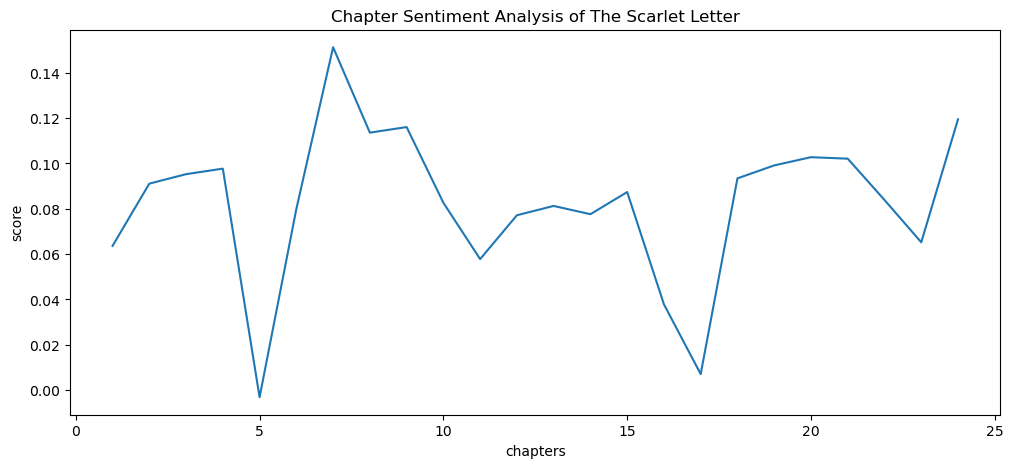

In [35]:
numbers = list(range(1, 25))
plt.figure(figsize=(12,5))     
plt.plot(numbers, scores)  
plt.title("Chapter Sentiment Analysis of The Scarlet Letter")         
plt.xlabel("chapters")         
plt.ylabel("score")         
plt.show() 

In [ ]:
## 4. Character Mention Tracking

In [36]:
def count_mentions_per_chapter(chapters, characters):
    chapter_counts = []
    for i, chapter_text in enumerate(chapters):
        counts = {char: 0 for char in characters.keys()}
        for name, aliases in characters.items():
            counts[name] = sum(chapter_text.count(alias) for alias in aliases)
        chapter_counts.append(counts)
    return chapter_counts

results = count_mentions_per_chapter(chapters, characters)
print(results[0])

{'Hester Prynne': 0, 'Arthur Dimmesdale': 0, 'Roger Chillingworth': 0, 'Pearl': 0}


In [37]:
print("Hester" in chapters[0])

False


In [38]:
print(chapters[0][:500])

THE PRISON-DOOR.



A throng of bearded men,
in sad-colored garments, and
gray, steeple-crowned hats, intermixed
with women, some
wearing hoods and others
bareheaded, was assembled in
front of a wooden edifice, the
door of which was heavily
timbered with oak, and studded
with iron spikes.
The founders of a new colony,
whatever Utopia of human virtue and happiness they might
originally project, have invariably recognized it among their earliest
practical necessities to allot a portion of the virg


In [39]:
print("Hester" in chapters[1])

True


In [40]:
print(results[1])

{'Hester Prynne': 17, 'Arthur Dimmesdale': 2, 'Roger Chillingworth': 0, 'Pearl': 0}


In [41]:
hester_counts = [r['Hester Prynne'] for r in results]
pearl_counts = [r['Pearl'] for r in results]
dimmesdale_counts = [r['Arthur Dimmesdale'] for r in results]
chillingworth_counts = [r['Roger Chillingworth'] for r in results]

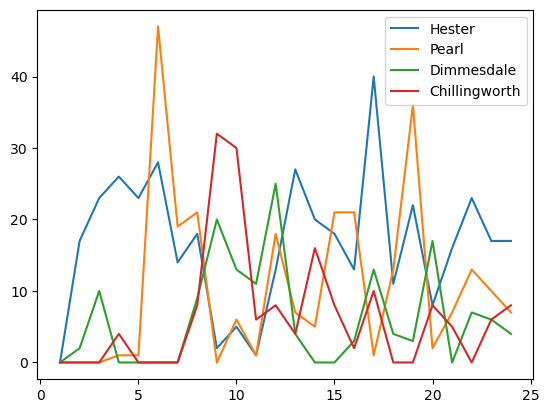

In [42]:
plt.plot(numbers, hester_counts, label='Hester')
plt.plot(numbers, pearl_counts, label='Pearl')
plt.plot(numbers, dimmesdale_counts, label='Dimmesdale')
plt.plot(numbers, chillingworth_counts, label='Chillingworth')
plt.legend()

In [43]:
!pip install nltk
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/e7064504-ddd6-401c-ad51-
[nltk_data]     fc9e2a17bdc4/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /home/e7064504-ddd6-401c-ad51-
[nltk_data]     fc9e2a17bdc4/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [44]:
from collections import Counter

In [45]:
words = re.findall(r'\b[a-zA-Z]+\b', novel.lower())

In [46]:
filtered_words = [w for w in words if w not in stop_words and len(w) > 3]
word_counts = Counter(filtered_words)
print(word_counts.most_common(20))

[('hester', 400), ('pearl', 250), ('thou', 237), ('would', 232), ('child', 222), ('little', 197), ('minister', 186), ('mother', 184), ('prynne', 168), ('could', 156), ('might', 152), ('upon', 150), ('said', 144), ('heart', 130), ('dimmesdale', 125), ('letter', 125), ('life', 125), ('like', 122), ('scarlet', 106), ('hand', 102)]


In [47]:
custom_stops = {'would', 'could', 'might', 'upon', 'said', 'thou', 'like'}
filtered_words = [w for w in words if w not in stop_words 
                  and w not in custom_stops 
                  and len(w) > 3]

In [48]:
filtered_words = [w for w in words if w not in stop_words and len(w) > 3]
word_counts = Counter(filtered_words)
print(word_counts.most_common(20))

[('hester', 400), ('pearl', 250), ('thou', 237), ('would', 232), ('child', 222), ('little', 197), ('minister', 186), ('mother', 184), ('prynne', 168), ('could', 156), ('might', 152), ('upon', 150), ('said', 144), ('heart', 130), ('dimmesdale', 125), ('letter', 125), ('life', 125), ('like', 122), ('scarlet', 106), ('hand', 102)]


In [49]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


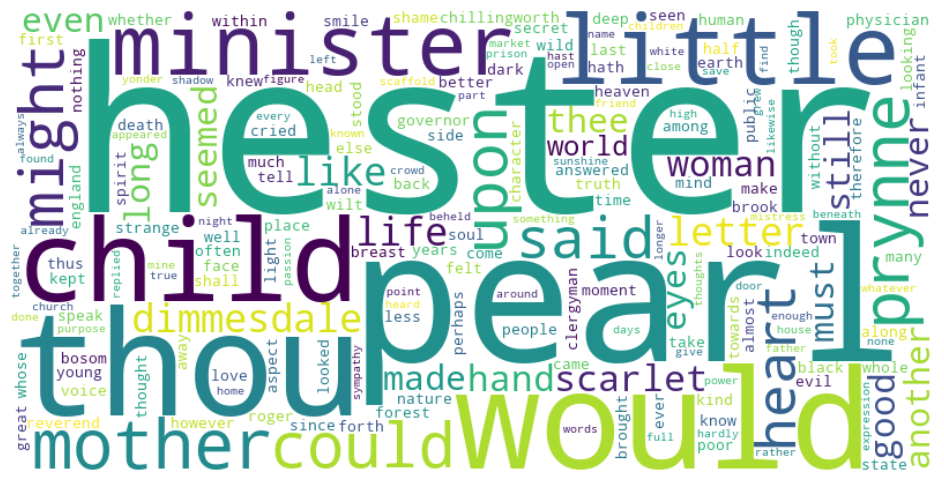

In [50]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=400, background_color='white')
wc.generate_from_frequencies(word_counts)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
## 5. Collocate Analysis: How are characters written differently?

In [51]:
def get_context_words(text, name, window=10):
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    context = []
    for i, word in enumerate(words):
        if word == name.lower():
            context.extend(words[i-window:i+window])
    return context

In [52]:
hester_context = get_context_words(novel, "Hester")
dimmesdale_context = get_context_words(novel, "Dimmesdale")
print(len(hester_context))
print(len(dimmesdale_context))

8000
2500


In [56]:
hester_filtered = [w for w in hester_context if w not in stop_words and len(w) > 3]
hester_counts = Counter(hester_filtered)
print (hester_counts.most_common(20))

[('hester', 421), ('prynne', 167), ('thou', 63), ('said', 50), ('pearl', 47), ('little', 36), ('child', 34), ('answered', 27), ('letter', 24), ('scarlet', 23), ('could', 22), ('thee', 22), ('would', 20), ('bosom', 19), ('upon', 19), ('minister', 19), ('heart', 18), ('never', 17), ('eyes', 17), ('dimmesdale', 17)]


In [57]:
dimmesdale_filtered = [w for w in dimmesdale_context if w not in stop_words and len(w) > 3]
dimmesdale_counts = Counter(dimmesdale_filtered)
print (dimmesdale_counts.most_common(20))

[('dimmesdale', 125), ('reverend', 34), ('arthur', 22), ('hester', 15), ('said', 14), ('thou', 9), ('upon', 8), ('physician', 8), ('master', 7), ('eyes', 7), ('hand', 6), ('make', 6), ('would', 6), ('another', 5), ('good', 5), ('woman', 5), ('young', 5), ('child', 5), ('whose', 5), ('even', 5)]


In [58]:
hester_words, hester_top_counts = zip(*hester_counts.most_common(10))
print(hester_words)
print(hester_top_counts)

('hester', 'prynne', 'thou', 'said', 'pearl', 'little', 'child', 'answered', 'letter', 'scarlet')
(421, 167, 63, 50, 47, 36, 34, 27, 24, 23)


In [59]:
dimmesdale_words, dimmesdale_top_counts = zip(*dimmesdale_counts.most_common(10))
print(dimmesdale_words)
print(dimmesdale_top_counts)

('dimmesdale', 'reverend', 'arthur', 'hester', 'said', 'thou', 'upon', 'physician', 'master', 'eyes')
(125, 34, 22, 15, 14, 9, 8, 8, 7, 7)


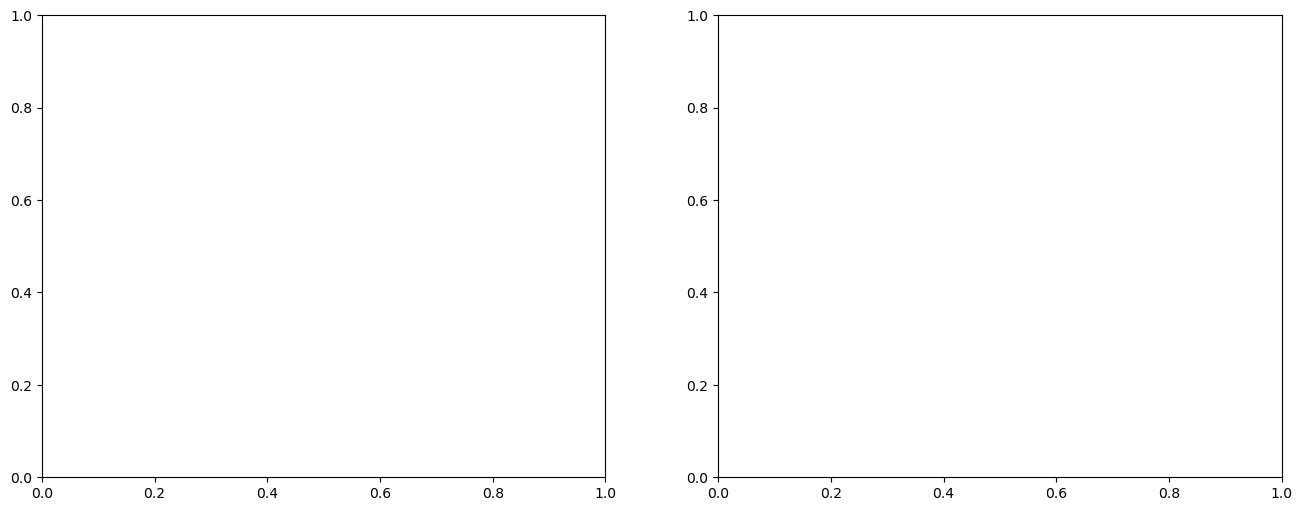

In [78]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

In [79]:
ax1.bar(hester_words, hester_top_counts, color='red')
ax1.set_title("Words Associated with Hester")
ax1.set_xlabel("Words")
ax1.set_ylabel("Frequency")
ax1.tick_params(axis='x', rotation=45)

In [80]:
ax2.bar(dimmesdale_words, dimmesdale_top_counts, color='blue')
ax2.set_title("Words Associated with Dimmesdale")
ax2.set_xlabel("Words")
ax2.set_ylabel("Frequency")
ax2.tick_params(axis='x', rotation=45)

In [81]:
hester_custom_stops = {'hester', 'prynne', 'said', 'thou', 'upon'} 
dimmesdale_custom_stops = {'dimmesdale', 'arthur', 'said', 'thou', 'upon'}
hester_filtered = [w for w in hester_context if w not in stop_words and w not in hester_custom_stops and len(w)>3]
dimmesdale_filtered = [w for w in dimmesdale_context if w not in stop_words and w not in dimmesdale_custom_stops and len(w) > 3]
hester_counts = Counter(hester_filtered)
dimmesdale_counts = Counter(dimmesdale_filtered)

In [85]:
pythonhester_words, hester_top_counts = zip(*hester_counts.most_common(10))
dimmesdale_words, dimmesdale_top_counts = zip(*dimmesdale_counts.most_common(10))

In [86]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

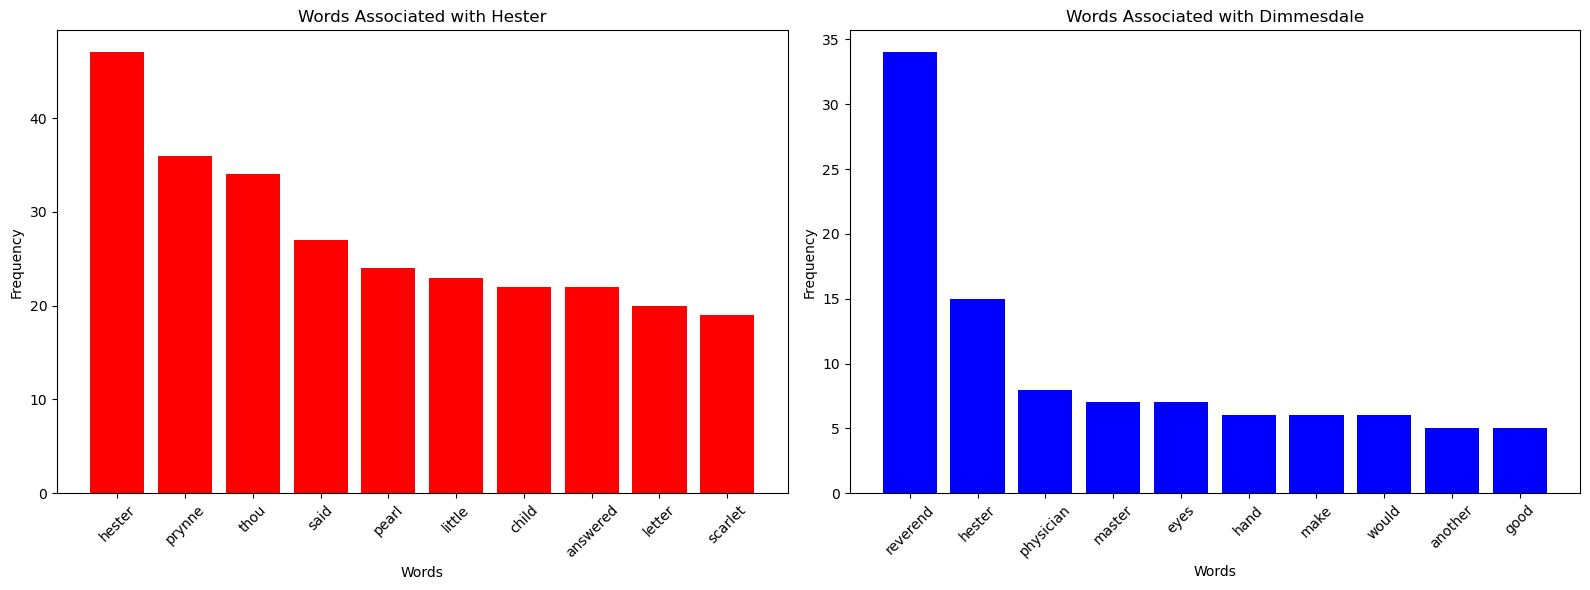

In [87]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(hester_words, hester_top_counts, color='red')
ax1.set_title("Words Associated with Hester")
ax1.set_xlabel("Words")
ax1.set_ylabel("Frequency")
ax1.tick_params(axis='x', rotation=45)

ax2.bar(dimmesdale_words, dimmesdale_top_counts, color='blue')
ax2.set_title("Words Associated with Dimmesdale")
ax2.set_xlabel("Words")
ax2.set_ylabel("Frequency")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [100]:
hester_custom_stops = {'hester', 'prynne', 'said', 'thou', 'upon', 'thee', 'would'}
dimmesdale_custom_stops = {'dimmesdale', 'arthur', 'said', 'thou', 'upon', 'would','hester', 'woman'}
hester_filtered = [w for w in hester_context if w not in stop_words and w not in hester_custom_stops and len(w) > 3]
dimmesdale_filtered = [w for w in dimmesdale_context if w not in stop_words and w not in dimmesdale_custom_stops and len(w) > 3]


In [101]:
hester_counts = Counter(hester_filtered)
dimmesdale_counts = Counter(dimmesdale_filtered)


In [102]:
hester_words, hester_top_counts = zip(*hester_counts.most_common(10))
dimmesdale_words, dimmesdale_top_counts = zip(*dimmesdale_counts.most_common(10))

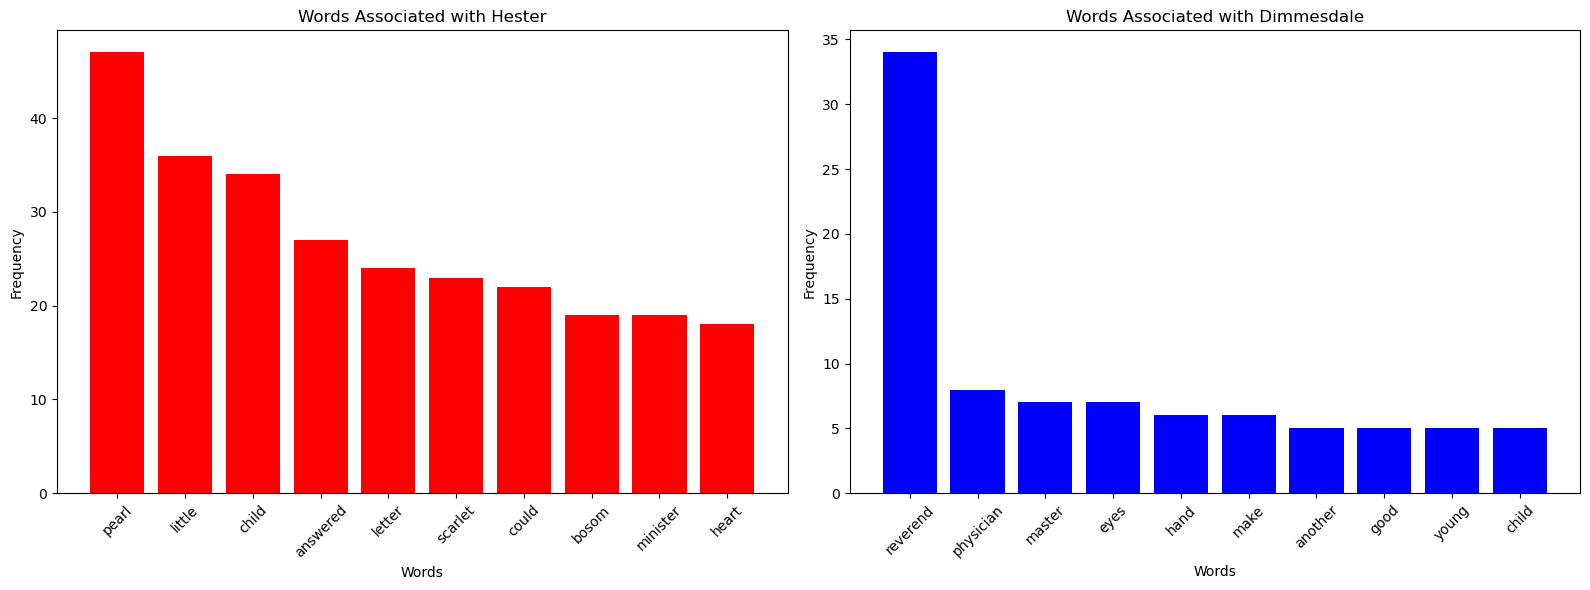

In [103]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(hester_words, hester_top_counts, color='red')
ax1.set_title("Words Associated with Hester")
ax1.set_xlabel("Words")
ax1.set_ylabel("Frequency")
ax1.tick_params(axis='x', rotation=45)

ax2.bar(dimmesdale_words, dimmesdale_top_counts, color='blue')
ax2.set_title("Words Associated with Dimmesdale")
ax2.set_xlabel("Words")
ax2.set_ylabel("Frequency")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
## 6. Co-occurrence Analysis

In [96]:
for i, chapter in enumerate(chapters):
    if "Hester" in chapter and "Dimmesdale" in chapter:
        print(f"Chapter {i+1}")

Chapter 2
Chapter 3
Chapter 8
Chapter 9
Chapter 10
Chapter 11
Chapter 12
Chapter 13
Chapter 16
Chapter 17
Chapter 18
Chapter 19
Chapter 20
Chapter 22
Chapter 23
Chapter 24


In [97]:
both_chapters = []
for i, chapter in enumerate(chapters):
    if "Hester" in chapter and "Dimmesdale" in chapter:
        both_chapters.append(i)

In [99]:
both_scores = [scores[i] for i in both_chapters]
solo_scores = [scores[i] for i in range(24) if i not in both_chapters]

both_avg = sum(both_scores) / len(both_scores)
solo_avg = sum(solo_scores) / len(solo_scores)

print(f"Chapters with both characters: {both_avg:.4f}")
print(f"Chapters with one/neither: {solo_avg:.4f}")

Chapters with both characters: 0.0827
Chapters with one/neither: 0.0821
